#**Conway's Game of Life: Simulation and Deep Learning Prediction**
This notebook explores Conway's Game of Life, first by implementing its core simulation engine in Python. It then demonstrates how to generate a dataset of game board evolutions. The main objective is to apply deep learning techniques to predict the game's future states (the 'God' model) and even its past states (the 'Devil' model) using Convolutional Neural Networks. This showcases how neural networks can learn complex emergent behaviors from simple rules, providing insights into both predictive modeling and the inherent dynamics of cellular automata.

### The `Game` Class: Core Simulation Engine for Conway's Game of Life

This section outlines the `Game` class, which serves as the central simulation engine for Conway's Game of Life. It meticulously manages the grid's state and orchestrates the mathematical transitions between generations, adhering strictly to the game's famous rules.

#### 1. Initialization
-   **Purpose**: Sets up the initial state and dimensions of the game board.
-   **Mechanism**: The board can be initialized in two ways:
    -   Directly from a provided `numpy.ndarray` (e.g., a custom pattern).
    -   Generated randomly based on specified `size` (height, width), `density` (proportion of live cells), and an optional `seed` for reproducibility.

#### 2. Advancing Generations
-   **Purpose**: Calculates and updates the board state for a specified number of simulation steps.
-   **Efficient Neighbor Counting**: Leverages `scipy.signal.convolve2d` with a `3 x 3` kernel to count the active neighbors of every cell in a single, efficient operation.
-   **Toroidal Topology**: Achieves a wraparound effect for the board edges using `boundary = 'wrap'` in the convolution. This treats the grid as a continuous surface, preventing edge effects.

#### 3. Evolution Rules
The `next` method applies the following rules to determine the state of each cell in the subsequent generation:
*   **Survival**: An active (live) cell remains active if it has exactly 2 or 3 active neighbors.
*   **Birth**: An inactive (dead) cell becomes active if it has exactly 3 active neighbors.
*   **Death**: Any other count of active neighbors leads to an inactive cell. This covers cases of underpopulation (fewer than 2 neighbors) and overpopulation (more than 3 neighbors), both causing the active cell to become inactive.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

class Game :

  def __init__(self, values : np.ndarray | None = None, size : tuple | None = None, density : float | None = 0.5, seed : int | None = None) :
    if not values is None:
      self.height = values.shape[0]
      self.width = values.shape[1]
      self.board = values
    elif size :
      self.height = size[0]
      self.width = size[1]
      if seed :
        np.random.seed(seed)
      self.board = np.array(np.random.random((self.height, self.width)) < density, dtype = np.int8)

  def update(self, steps : int | None = 1) :
    if not steps :
      return self.board

    previous = self.board
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for _ in range(steps) :
      neighbours = scipy.signal.convolve2d(previous, kernel, mode = 'same', boundary = 'wrap')

      output = np.zeros_like(previous, dtype = np.int8)
      suvive = (previous == 1) & ((neighbours == 2) | (neighbours == 3))
      reproduce = (previous == 0) & (neighbours == 3)

      output[suvive | reproduce] = 1
      previous = output

    self.board = previous
    return self.board

### Plotting and Initializing the Game Board

This section introduces a `plot` utility function and demonstrates the initialization of a `Game` object, specifically named `Life`, with an initial random board configuration.

-   The `plot` function is a simple utility that visualizes the game board at any given state. It uses `matplotlib.pyplot.imshow` to render the 2D `numpy.ndarray` representing the board, employing a binary colormap to distinguish between live (black) and dead (white) cells.

-   A `Life` game object is then initialized by calling the `Game` class constructor with:
    -   `size = (60, 120)`: Setting the board dimensions to 60 rows (height) and 120 columns (width).
    -   `density = 0.35`: Determining that approximately 35% of cells will start as 'live'.
    -   `seed = 2005`: Ensuring the initial board configuration is reproducible for consistent results.

-   Finally, `plot(Life.board)` is called to display this newly initialized random board, providing a visual representation of the starting state before the simulation begins.

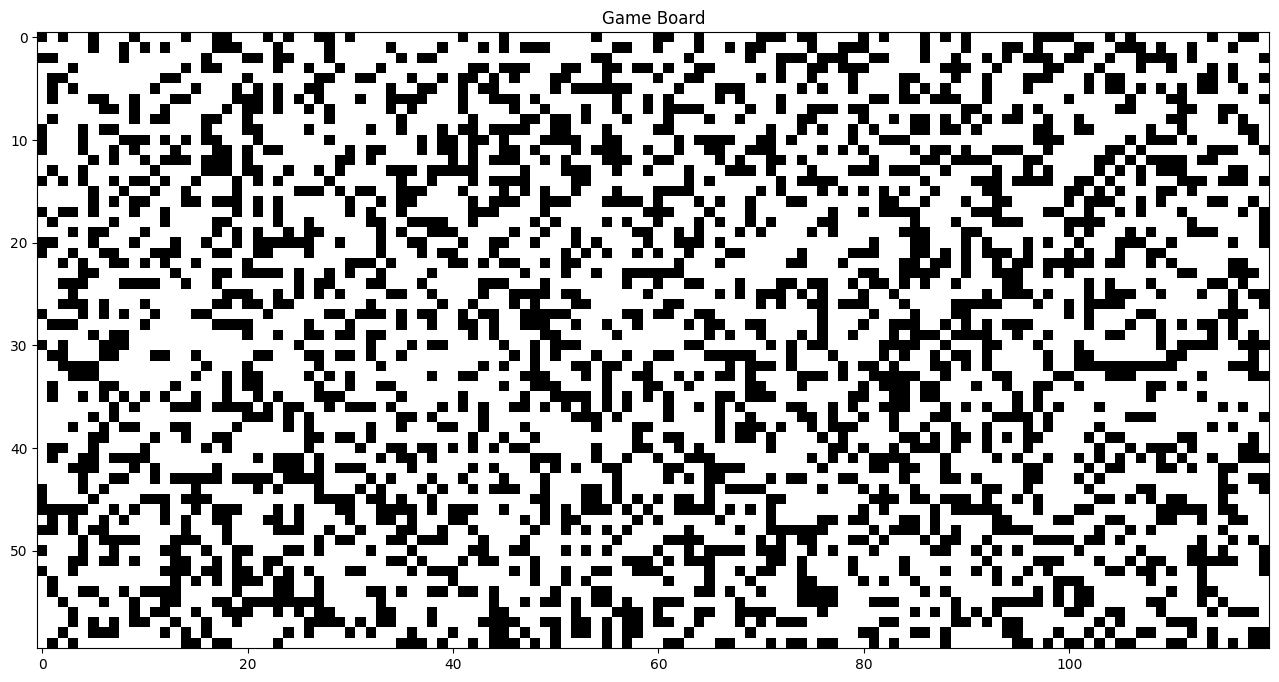

In [14]:
def plot(values : np.ndarray) :
  plt.figure(figsize = (16, 8))
  plt.imshow(values, cmap = 'binary')
  plt.title("Game Board")
  plt.show()

Life = Game(size = (60, 120), density = 0.35, seed = 2005)
plot(Life.board)

### The `GenerateData` Function: Creating Datasets of Game of Life Evolutions

This section introduces the `GenerateData` function, a utility designed to automate the process of creating multiple Conway's Game of Life simulations and structuring their evolving states into a Pandas DataFrame. This is particularly useful for generating datasets for machine learning tasks, where input and output states are required.

#### Function Purpose
-   To generate a collection of `Game` instances, each with a unique initial state.
-   To simulate the evolution of these games over a specified number of steps.
-   To organize the board states at each step into a Pandas DataFrame for easy access and further processing.

#### Parameters
-   `size` (`tuple`): Defines the dimensions `(height, width)` of the game board for each individual simulation.
-   `rows` (`int`): Specifies the total number of independent Game of Life simulations to generate and include in the dataset.
-   `steps` (`int | None = 2`): The number of generations each simulation will advance and record. Each step will correspond to a column in the output DataFrame.
-   `density` (`float | None = 0.35`): The initial probability of a cell being alive on the board for newly created games.
-   `seed` (`int | None = None`): An optional seed for NumPy's random number generator to ensure reproducibility of the initial game configurations across runs.

#### Example Usage
In the provided code, `GenerateData` is called to create a dataset named `Data` with:
-   Board `size` of `(24, 64)`.
-   `steps = 6`, meaning 6 generations are recorded.
-   `rows = 4`, indicating 4 distinct game simulations.
-   `density = 0.45`, setting the initial cell density.
-   A specific `seed = 205` for reproducibility.

The `display(Data)` call then shows the resulting DataFrame, where each cell contains a NumPy array representing the game board at a particular step for each simulation.

In [15]:
import pandas as pd
pd.set_option('display.max_colwidth', 50)

def GenerateData(size : tuple, rows : int, steps : int | None = 2, density : float | None = 0.35, seed : int | None = None) :
  if seed :
    np.random.seed(seed)
  seeds = np.random.randint(0, 99999, rows)

  games = [Game(size = size, density = density, seed = seeds[i]) for i in range(rows)]

  boards = [[] for _ in range(rows)]
  for row in range(rows):
      boards[row].append(games[row].board)

  for step in range(1, steps):
      for row in range(rows):
          games[row].update()
          boards[row].append(games[row].board)

  data = pd.DataFrame({step : [boards[row][step] for row in range(rows)] for step in range(steps)})
  return data

Data = GenerateData(size = (24, 64), steps = 6, rows = 4, density = 0.45, seed = 205)
display(Data)

,0,1,2,3,4,5
0,"[[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,...","[[0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,...","[[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,...","[[0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,...","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,..."
1,"[[0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,...","[[0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,...","[[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,...","[[0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,...","[[0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,..."
2,"[[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,...","[[1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,...","[[0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,...","[[0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,...","[[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,...","[[0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,..."
3,"[[0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,...","[[1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,...","[[1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,..."


### The `PlotData` Function: Visualizing Game of Life Evolutions

This section introduces the `PlotData` function, which is designed to visualize the sequential states of game boards stored within a Pandas DataFrame. It provides a clear, step-by-step graphical representation of how a Conway's Game of Life simulation evolves over time, making it easy to observe patterns and changes.

#### Function Purpose
-   To display the evolution of individual Game of Life simulations stored in a DataFrame.
-   To present each step of a simulation side-by-side for easy visual comparison.

#### Parameters
-   `Data` (`pd.DataFrame`): A Pandas DataFrame where each row represents a distinct Game of Life simulation, and each column contains a `numpy.ndarray` representing the board state at a particular generation.

#### Functionality Breakdown
1.  **Iterating Through Simulations**: The function loops through each row of the input `Data` DataFrame, treating each row as an independent Game of Life evolution.
2.  **Creating Subplots**: For each simulation, it creates a new figure with multiple subplots arranged horizontally. The number of subplots corresponds to the number of `steps` (columns) in the `Data` DataFrame, allowing all recorded states of a single simulation to be viewed simultaneously.
3.  **Displaying Board States**: Within each subplot, `matplotlib.pyplot.imshow` is used to render the 2D `numpy.ndarray` of the game board. A `binary` colormap is applied to clearly differentiate between live (typically black) and dead (typically white) cells.
4.  **Aesthetic Enhancements**: Each subplot is labeled with its corresponding 'Step' number (`f"Step {column}"`) for clarity. X and Y-axis ticks are removed to provide a cleaner visual of the board. `plt.tight_layout(pad=2)` is used to adjust subplot parameters automatically, ensuring that titles and labels do not overlap and that there is adequate spacing.

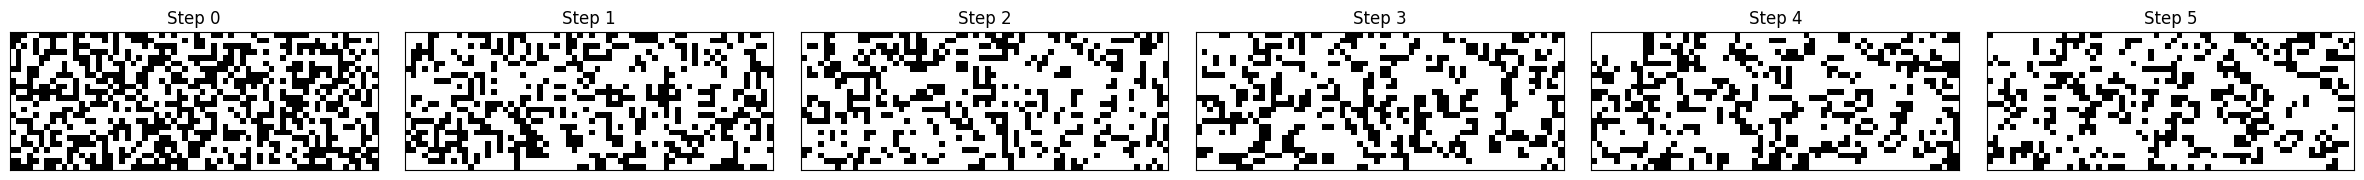

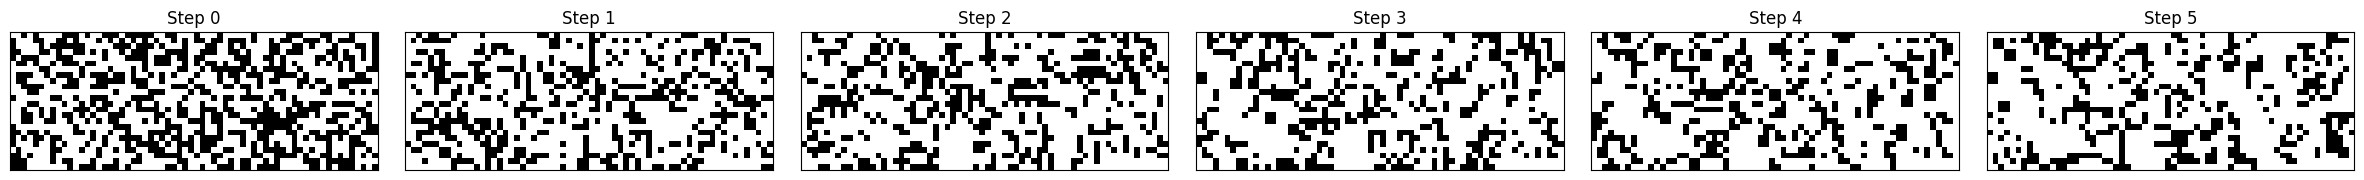

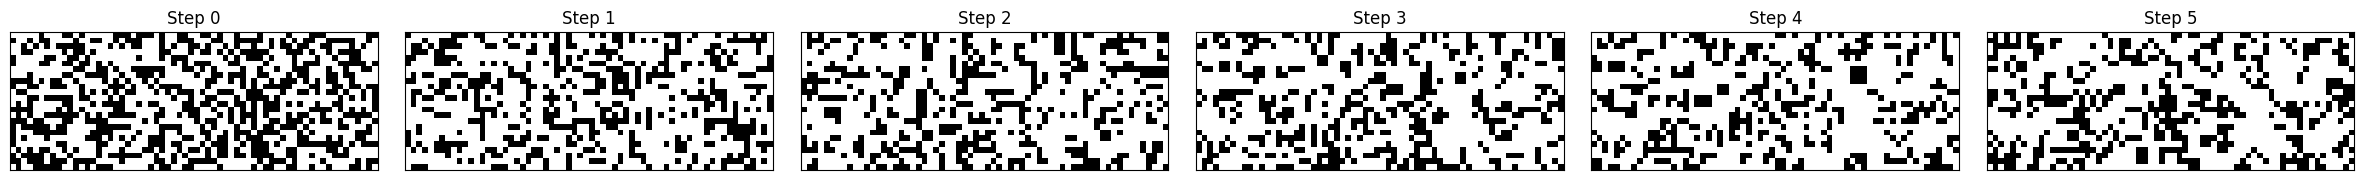

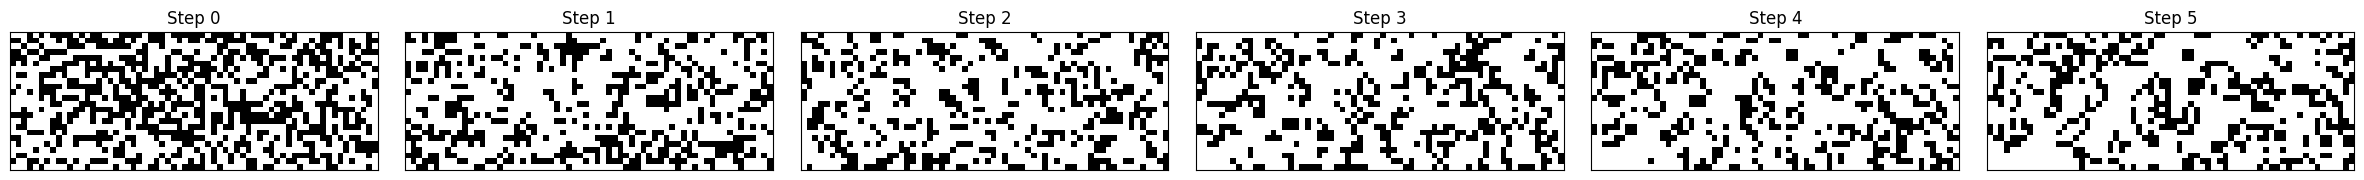

In [16]:
def PlotData(Data : pd.DataFrame) :
  for i in range(len(Data)) :
    fig, axes = plt.subplots(1, len(Data.columns), figsize = (len(Data.columns) * 4, 2))

    if len(Data.columns) == 1 :
        axes = [axes]

    for k, column in enumerate(Data.columns) :

      axes[k].imshow(Data.loc[i, column], cmap = 'binary')
      axes[k].set_title(f"Step {column}")
      axes[k].set_xticks([])
      axes[k].set_yticks([])

    plt.tight_layout(pad = 2)
    plt.show()

PlotData(Data = Data)

### Regenerating the Dataset for Machine Learning Training

To prepare for training a machine learning model, the `Data` DataFrame is being regenerated with a significantly larger set of simulations and specific board dimensions. This expanded dataset will provide a more robust foundation for the neural network to learn the Game of Life's evolution rules.

The parameters used for this regeneration are:
-   `height`: 32 (board height)
-   `width`: 64 (board width)
-   `steps`: 4 (number of generations simulated for each game)
-   `rows`: 512 (number of individual game simulations, representing a substantial increase from previous runs to create a rich training dataset)
-   `density`: 0.35 (initial density of live cells on the board)

This larger dataset is crucial for effectively training the neural network that will be introduced in the subsequent steps.

In [31]:
height, width = 32, 64
Data = GenerateData(size = (height, width), steps = 4, rows = 712, density = 0.35)

### The `SplitData` Function: Preparing Data for Model Training

This section introduces the `SplitData` function, which is essential for structuring the generated Game of Life simulation data into appropriate training and testing datasets for a neural network. It separates the input (start) and output (end) states and then partitions them for model development and evaluation.

#### Function Purpose
-   To extract specific 'start' and 'end' states from the DataFrame of game evolutions.
-   To divide these states into training and testing sets, enabling the evaluation of a model's performance on unseen data.

#### Parameters
-   `Data` (`pd.DataFrame`): The Pandas DataFrame containing the Game of Life board states at different steps.
-   `size` (`float | None = 0.8`): The proportion of the data to be allocated for the training set (e.g., 0.8 means 80% for training, 20% for testing).
-   `indices` (`tuple | None = None`): A tuple specifying the column indices to use as the 'start' and 'end' states. By default, it uses the second-to-last and last columns of the DataFrame, respectively.

#### Functionality Breakdown
1.  **State Extraction**: The function first identifies and extracts the specified 'start' and 'end' board states from the input `Data` DataFrame. These are converted into NumPy arrays and reshaped to include an additional dimension (`axis = -1`), which is often required for convolutional neural network inputs.
2.  **Dataset Splitting**: Based on the `size` parameter, these extracted 'start' and 'end' state arrays are then split into four distinct sets:
    -   `TrainStart`: Input boards for training.
    -   `TrainEnd`: Corresponding target boards for training.
    -   `TestStart`: Input boards for evaluating the model.
    -   `TestEnd`: Corresponding target boards for evaluating the model.

#### Visualization of Dataset Sizes
Following the data split, a bar chart is generated to visually represent the number of samples in the original `Data` and each of the newly created sets (`TrainStart`, `TrainEnd`, `TestStart`, `TestEnd`). This visualization provides a quick confirmation of the data partitioning and ensures the datasets are correctly sized for subsequent model training and validation.

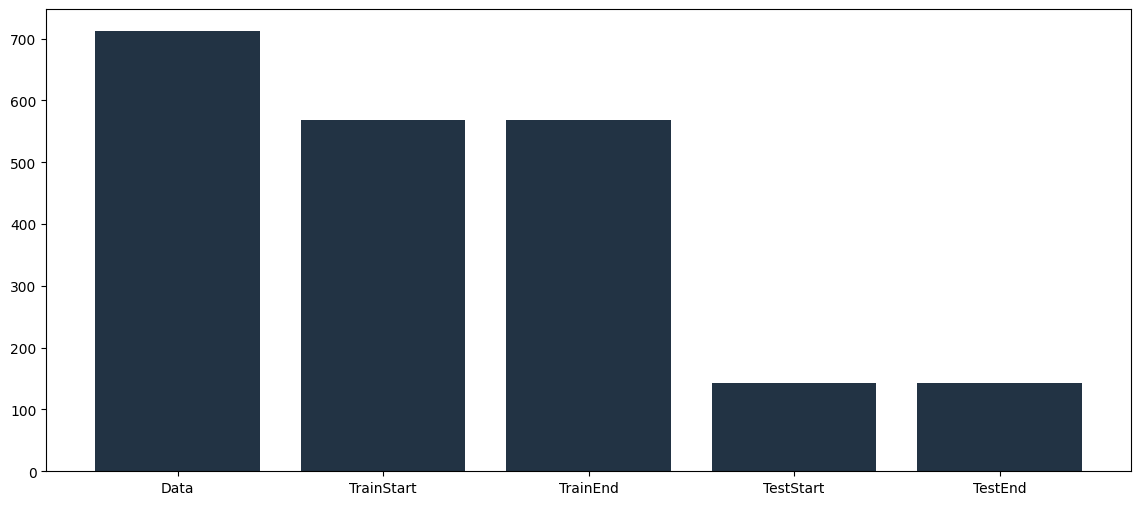

In [32]:
def SplitData(Data : pd.DataFrame, size : float | None = 0.8, indices : tuple | None = None) :
  if not indices :
    indices = (Data.columns[-2], Data.columns[-1])

  Start = np.expand_dims(np.array(Data[indices[0]].tolist()), axis = -1)
  End = np.expand_dims(np.array(Data[indices[1]].tolist()), axis = -1)

  TrainStart = Start[:int(size * len(Start))]
  TrainEnd = End[:int(size * len(Start))]

  TestStart = Start[int(size * len(Start)):]
  TestEnd = End[int(size * len(Start)):]

  return TrainStart, TrainEnd, TestStart, TestEnd

TrainStart, TrainEnd, TestStart, TestEnd = SplitData(Data, 0.8)

sizes = pd.Series({"Data" : len(Data), "TrainStart" : len(TrainStart), "TrainEnd" : len(TrainEnd), "TestStart" : len(TestStart), "TestEnd" : len(TestEnd)})

plt.figure(figsize = (14, 6))
plt.bar(sizes.index, sizes.values, color = "#223344")
plt.show()


### The Convolutional Neural Network (CNN) Model for Game of Life Prediction

This section introduces the neural network model designed to predict the next state of the Game of Life grid. A `CreateModel` function is defined to construct a Convolutional Neural Network (CNN) that learns the game's rules.

#### 1. `CreateModel` Function

-   **Purpose**: This function builds a sequential CNN model capable of processing 2D grid data, such as the Game of Life board. It takes the `shape` of the input grid (e.g., `height`, `width`) as an argument.
-   **Architecture**: The model primarily consists of `Conv2D` layers. A key feature is the inclusion of a `Lambda` layer implementing `CircularPadding` before each convolutional layer. This custom padding ensures a toroidal topology, mirroring the `boundary='wrap'` behavior used in the `Game` class's `convolve2d` operation, effectively treating the grid edges as continuous.
-   **Output**: The final layer is a `Conv2D` layer with a single filter and `sigmoid` activation, producing an output of the same dimensions as the input, with values between 0 and 1, representing the probability of a cell being alive.

#### 2. 'God' Model Initialization and Training

-   **Initialization**: The 'God' model is instantiated by calling `CreateModel` with the predefined `height` and `width` of the game board. This sets up the CNN structure.
-   **Compilation**: The model is then compiled with:
    -   `optimizer = 'Adam'`: A popular and effective optimization algorithm for training neural networks.
    -   `loss = 'binary_crossentropy'`: This loss function is suitable for binary classification problems, where each cell's state (alive or dead) is predicted.
    -   `metrics = ['accuracy']`: To monitor the proportion of correctly predicted cell states during training.
-   **Training (`God.fit()`)**: The 'God' model is trained using the generated Game of Life data.
    -   `TrainStart`: The input data, representing the initial states of the game boards.
    -   `TrainEnd`: The target data, representing the next states of the game boards that the model aims to predict.
    -   `epochs = 10`: The model will iterate over the entire training dataset 10 times.
    -   `validation_data = (TestStart, TestEnd)`: A separate dataset (`TestStart` and `TestEnd`) is used to evaluate the model's performance on unseen data after each epoch, helping to detect overfitting.

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, Lambda
from tensorflow.keras.optimizers import Adam

def CreateModel(shape : tuple, filter : int | None = 32) :
  def CircularPadding(x):
      height = tf.shape(x)[1]
      width = tf.shape(x)[2]

      padded = tf.concat([x[:, height-1:, :, :], x, x[:, :1, :, :]], axis = 1)
      return tf.concat([padded[:, :, width-1:, :], padded, padded[:, :, :1, :]], axis = 2)

  return Sequential([
      Input(shape = shape + (1,)),

      Lambda(CircularPadding),
      Conv2D(filter, (3, 3), activation = 'relu', padding='valid'),

      Lambda(CircularPadding),
      Conv2D(filter, (3, 3), activation = 'relu', padding='valid'),

      Lambda(CircularPadding),
      Conv2D(filter, (3, 3), activation = 'relu', padding='valid'),

      Conv2D(1, (1, 1), activation = 'sigmoid', padding='valid')
      ])

God = CreateModel(shape = (height, width))
God.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

Ghistory = God.fit(TrainStart, TrainEnd, epochs = 10, validation_data = (TestStart, TestEnd))

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.6937 - loss: 0.6474 - val_accuracy: 0.7014 - val_loss: 0.5990
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step - accuracy: 0.7007 - loss: 0.5848 - val_accuracy: 0.7140 - val_loss: 0.5439
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.7298 - loss: 0.5301 - val_accuracy: 0.7693 - val_loss: 0.4851
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 350ms/step - accuracy: 0.7791 - loss: 0.4665 - val_accuracy: 0.8015 - val_loss: 0.3951
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.8190 - loss: 0.3679 - val_accuracy: 0.8925 - val_loss: 0.2763
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.9199 - loss: 0.2412 - val_accuracy: 0.9847 - val_loss: 0.1396
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.9906 - loss: 0.1149 - val_accuracy: 0.9991 - val_loss: 0.0551
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step - accuracy: 0.9996 - loss: 0.0445 - val_accuracy: 1

### The `PlotHistory` Function: Visualizing Training Progress

The `PlotHistory` function is designed to visualize the training and validation metrics (loss and accuracy) over the epochs of a model's training process. This function takes a Keras `history` object (which is returned by the `fit` method) as its input.

#### Functionality:
*   It generates two separate subplots within a single figure:
    *   **Left Subplot**: Displays the 'Train Loss' and 'Validation Loss' over each epoch.
    *   **Right Subplot**: Displays the 'Train Accuracy' and 'Validation Accuracy' over each epoch.
*   Each subplot includes a title, appropriate labels for the x and y axes, and a legend to distinguish between training and validation metrics.
*   Gridlines are added for better readability.

This visualization is crucial for monitoring model performance, detecting overfitting or underfitting, and understanding the learning dynamics throughout the training duration.

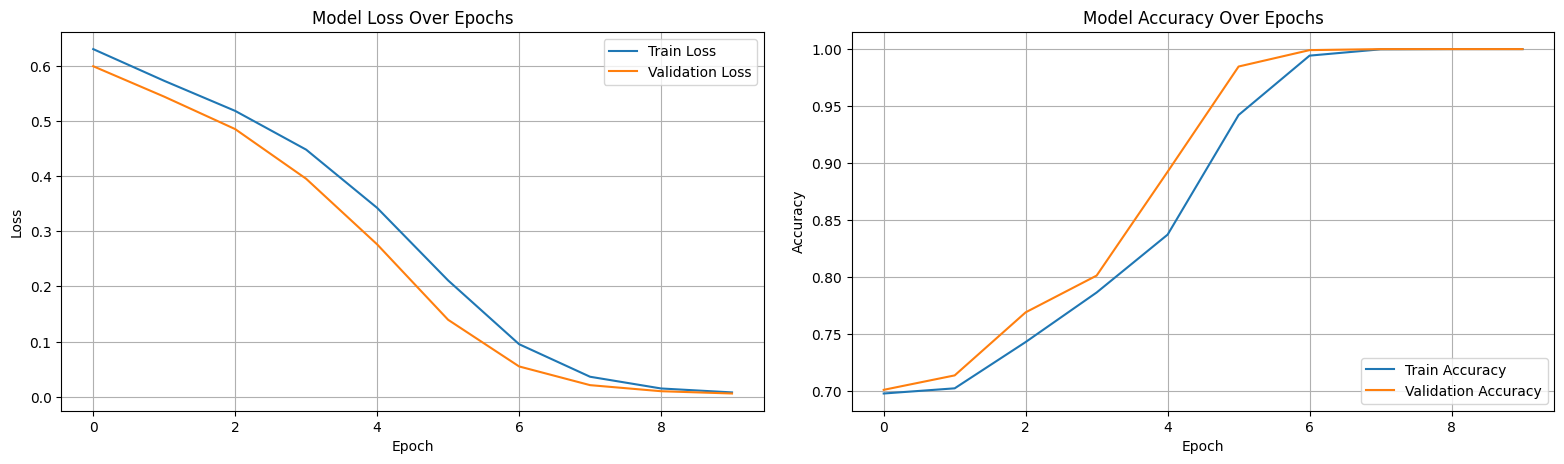

In [34]:
def PlotHistory(history) :
  fig, axes = plt.subplots(1, 2, figsize = (16, 5))

  axes[0].plot(history.history['loss'], label='Train Loss')
  axes[0].plot(history.history['val_loss'], label='Validation Loss')
  axes[0].set_title('Model Loss Over Epochs')
  axes[0].set_ylabel('Loss')
  axes[0].set_xlabel('Epoch')
  axes[0].legend(loc='upper right')
  axes[0].grid(True)

  axes[1].plot(history.history['accuracy'], label='Train Accuracy')
  axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
  axes[1].set_title('Model Accuracy Over Epochs')
  axes[1].set_ylabel('Accuracy')
  axes[1].set_xlabel('Epoch')
  axes[1].legend(loc='lower right')
  axes[1].grid(True)

  plt.tight_layout(pad = 2)
  plt.show()

PlotHistory(Ghistory)

### The `Evaluate` Function: Qualitative Model Assessment

This section introduces the `Evaluate` function, designed for a qualitative assessment of a trained model's predictions. It visually compares the model's output against the actual ground truth for a few examples, providing insights into its accuracy and error types.

#### Function Purpose
-   To visually inspect how well the model's predictions align with the true outcomes.
-   To provide a detailed breakdown of prediction errors, including True Positives, True Negatives, False Positives, and False Negatives.

#### Parameters
-   `model`: The trained neural network model (e.g., `God` or `Devil`).
-   `Test`: A tuple containing the test input data (`TestStart`) and the corresponding true output data (`TestEnd`).
-   `examples` (`int | None = 5`): The number of test cases to visualize.

#### Functionality Breakdown
1.  **Prediction**: The function first uses the provided `model` to generate predictions on `TestStart` and binarizes them (values > 0.5 become 1).
2.  **Visualization Loop**: For each of the specified `examples`, it generates a figure with five subplots:
    -   **'Start'**: The initial state provided as input to the model.
    -   **'End'**: The actual target state that the model should predict.
    -   **'Predicted'**: The state predicted by the model.
    -   **'Errors'**: A visual map highlighting where the `Predicted` state differs from the `End` state, typically using a distinct color (e.g., red) for mismatches.
    -   **'Stats'**: A bar chart summarizing the prediction performance across four categories:
        -   `TP` (True Positives): Correctly predicted live cells.
        -   `TN` (True Negatives): Correctly predicted dead cells.
        -   `FP` (False Positives): Dead cells incorrectly predicted as live.
        -   `FN` (False Negatives): Live cells incorrectly predicted as dead.

This qualitative and quantitative breakdown is crucial for understanding the model's performance beyond simple accuracy metrics, revealing specific patterns of success and failure.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


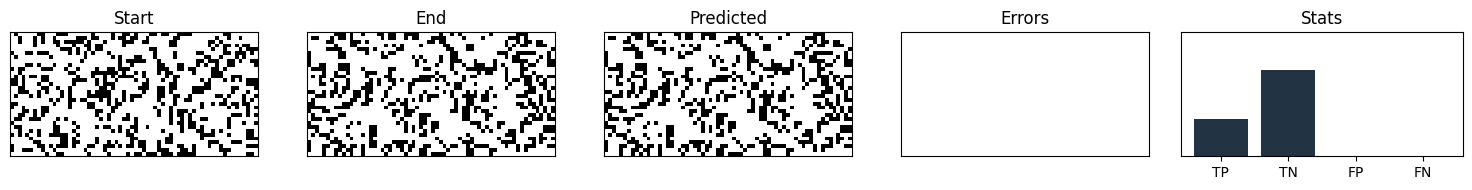

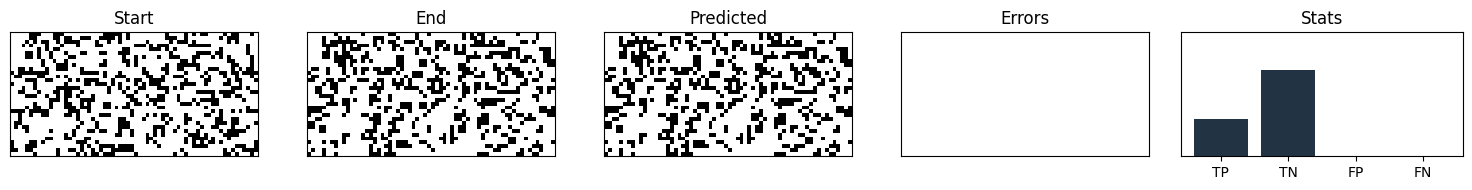

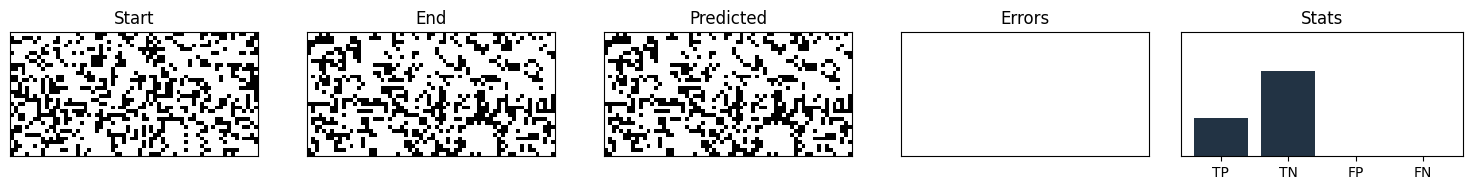

In [35]:
from matplotlib.colors import LinearSegmentedColormap

def Evaluate(model, Test,examples : int | None = 5) :
  TestStart, TestEnd = Test
  Predicted = (model.predict(TestStart) > 0.5).astype(int)

  for i in range(min(examples, len(TestStart))):
      fig, axes = plt.subplots(1, 5, figsize = (15, 2))

      axes[0].imshow(TestStart[i].squeeze(), cmap='binary')
      axes[0].set_title('Start')
      axes[0].set_xticks([])
      axes[0].set_yticks([])

      axes[1].imshow(TestEnd[i].squeeze(), cmap='binary')
      axes[1].set_title('End')
      axes[1].set_xticks([])
      axes[1].set_yticks([])

      axes[2].imshow(Predicted[i].squeeze(), cmap='binary')
      axes[2].set_title('Predicted')
      axes[2].set_xticks([])
      axes[2].set_yticks([])

      axes[3].imshow((Predicted[i].squeeze() != TestEnd[i].squeeze()).astype(int), cmap = LinearSegmentedColormap.from_list('RedWhite', ['white', 'red'], N = 2))
      axes[3].set_title('Errors')
      axes[3].set_xticks([])
      axes[3].set_yticks([])

      P = Predicted[i].squeeze() == 1
      N = Predicted[i].squeeze() == 0

      T = TestEnd[i].squeeze() == 1
      F = TestEnd[i].squeeze() == 0

      Stats = {"TP": (T & P).sum(), "TN": (F & N).sum(), "FP": (F & P).sum(), "FN": (T & N).sum()}

      height, width = Predicted[i].squeeze().shape

      axes[4].bar(Stats.keys(), Stats.values(), color=['#223344', '#223344', '#663737', '#663737'])
      axes[4].set_ylim(0, height * width)
      axes[4].set_title('Stats')
      axes[4].set_yticks([])

      plt.tight_layout()
      plt.show()

Evaluate(God, (TestStart, TestEnd), examples = 3)

### The 'Devil' Model: Learning the Inverse Dynamics

While the 'God' model predicts the *next* state of the Game of Life, the 'Devil' model is designed to learn the *inverse* dynamics – predicting the *previous* state of the game board given its current state. This demonstrates the flexibility of the CNN architecture to learn both forward and backward temporal relationships within the Game of Life.

#### Model Initialization and Training:

-   **Initialization**: Similar to the 'God' model, the 'Devil' model is instantiated using the `CreateModel` function with the same `height` and `width` dimensions, ensuring an identical CNN architecture.

-   **Compilation**: The compilation process also mirrors that of the 'God' model, using:
    -   `optimizer = 'Adam'` for optimization.
    -   `loss = 'binary_crossentropy'` as the loss function, suitable for binary cell state prediction.
    -   `metrics = ['accuracy']` to monitor performance during training.

-   **Training (`Devil.fit()`):** The key difference lies in the input and target data used for training:
    -   `TrainEnd`: Is now used as the input data, representing the 'current' state of the game boards.
    -   `TrainStart`: Is used as the target data, representing the 'previous' state that the model tries to reconstruct from `TrainEnd`.
    -   `epochs = 10`: The model is trained for 10 epochs.
    -   `validation_data = (TestEnd, TestStart)`: The validation data is similarly inverted, with `TestEnd` as input and `TestStart` as target, to evaluate the model's inverse prediction capabilities on unseen data.

This inverse training setup challenges the model to reverse-engineer the Game of Life rules, which is often a more complex task than predicting the forward evolution.

In [36]:

Devil = CreateModel(shape = (height, width))
Devil.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

Dhistory = Devil.fit(TrainEnd, TrainStart, epochs = 10, validation_data = (TestEnd, TestStart))

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 0.6657 - loss: 0.6578 - val_accuracy: 0.6889 - val_loss: 0.6171
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 283ms/step - accuracy: 0.6887 - loss: 0.6074 - val_accuracy: 0.6893 - val_loss: 0.5828
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.6952 - loss: 0.5795 - val_accuracy: 0.7106 - val_loss: 0.5708
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.7116 - loss: 0.5682 - val_accuracy: 0.7177 - val_loss: 0.5637
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 349ms/step - accuracy: 0.7179 - loss: 0.5613 - val_accuracy: 0.7220 - val_loss: 0.5578
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - accuracy: 0.7244 - loss: 0.5545 - val_accuracy: 0.7266 - val_loss: 0.5509
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.7270 - loss: 0.5475 - val_accuracy: 0.7287 - val_loss: 0.5446
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.7299 - loss: 0.5416 - val_accuracy: 0.

### Plotting 'Devil' Model Training History

This section visualizes the training history of the 'Devil' model. Similar to the 'God' model, the `PlotHistory` function is employed to display the training and validation loss and accuracy over the epochs. This visualization helps in understanding how well the 'Devil' model is learning the inverse dynamics of the Game of Life and identifying any signs of overfitting or underfitting during its training process.

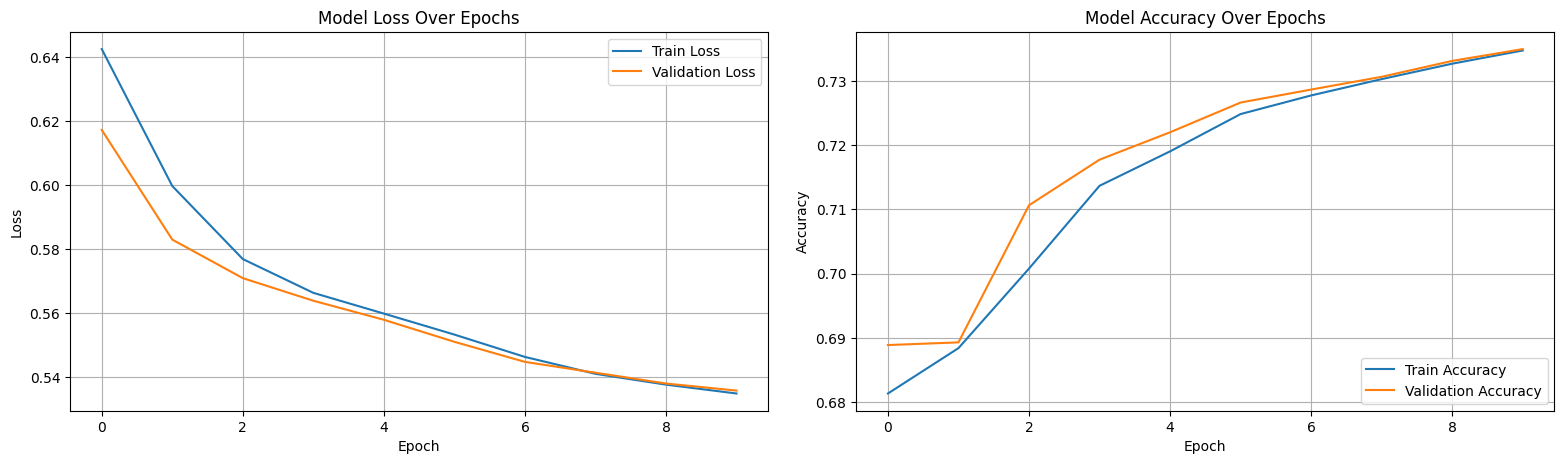

In [37]:
PlotHistory(Dhistory)

### Evaluating the 'Devil' Model: Inverse Prediction Performance

This section utilizes the `Evaluate` function to qualitatively assess the 'Devil' model's performance in predicting the *previous* state of the Game of Life board. Just as with the 'God' model, this evaluation provides a visual and statistical breakdown of how well the model reconstructs past states from current ones.

#### Key Aspects of Evaluation:

-   **Visual Comparison**: For a specified number of `examples` from the test set (`TestEnd` as input, `TestStart` as target), the function displays:
    -   The `TestEnd` (current state) that was fed into the 'Devil' model.
    -   The actual `TestStart` (previous state) as the ground truth.
    -   The model's `Predicted` previous state.
-   **Error Visualization**: A dedicated plot highlights `Errors` by marking discrepancies between the `Predicted` and actual `TestStart` states, helping to identify where the model struggles in its inverse prediction task.
-   **Statistical Breakdown**: A bar chart provides `Stats` on True Positives, True Negatives, False Positives, and False Negatives, giving quantitative insight into the model's accuracy in identifying live and dead cells when looking backward in time.

This evaluation is crucial for understanding the 'Devil' model's ability to 'undo' the Game of Life's evolution rules, offering a deeper insight into its learned inverse dynamics.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


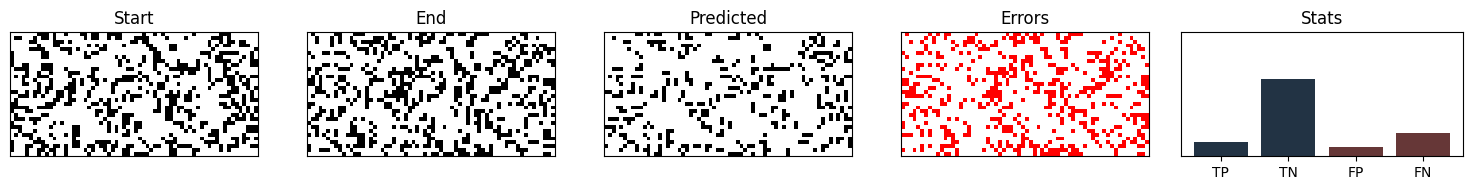

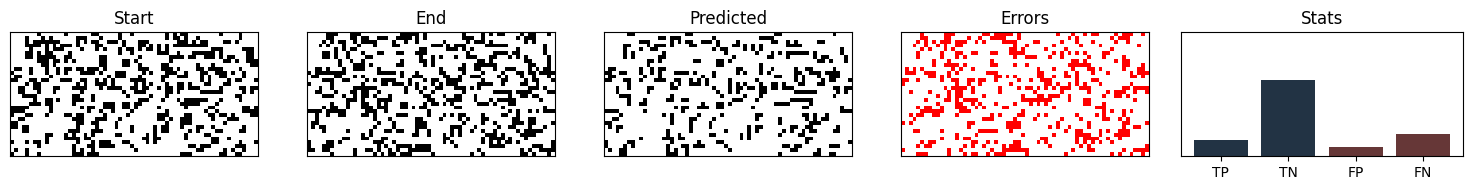

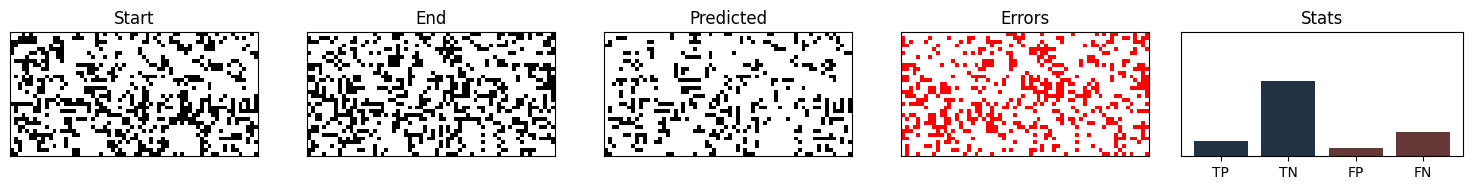

In [38]:
Evaluate(Devil, (TestEnd, TestStart), examples = 3)

### Conclusion and Model Performance Insights

This notebook has taken us on a journey through Conway's Game of Life, from its fundamental Python implementation to its exploration using deep learning. We first established the core simulation logic, then generated a dataset of game board evolutions. Finally, we trained two Convolutional Neural Networks: the 'God' model, designed to predict the next state, and the 'Devil' model, tasked with predicting the previous state.

#### Why the 'God' Model Performed Exceptionally (Near 100% Accuracy) and the 'Devil' Model Achieved Lower Accuracy (Around 73%)

The stark difference in performance between the 'God' and 'Devil' models highlights a fundamental characteristic of the Game of Life's rules and the nature of forward versus inverse problems:

1.  **The 'God' Model (Forward Prediction):** The rules of Conway's Game of Life are **deterministic and local**. The state of any given cell in the next generation is uniquely and entirely determined by its own state and the states of its eight immediate neighbors in the current generation. Our `CreateModel` architecture, using `Conv2D` layers with `CircularPadding`, is perfectly suited to capture these local, grid-based interactions. The convolutional filters can effectively learn the precise 3x3 rules for survival and reproduction. Because the mapping from an input 3x3 neighborhood to an output cell state is a one-to-one, deterministic function, the 'God' model, with sufficient data and a well-suited architecture, can learn this mapping with very high (even near 100%) accuracy.

2.  **The 'Devil' Model (Inverse Prediction):** Predicting the previous state from the current one is an **inherently much more difficult and often non-deterministic problem**. The rules of the Game of Life are designed for forward evolution, and reversing them introduces significant ambiguity. For instance:
    *   A dead cell in the current generation could have been a live cell that died from underpopulation (fewer than 2 neighbors) or overpopulation (more than 3 neighbors), or it could have simply been a dead cell that remained dead. Without additional context, it's impossible to uniquely determine its prior state.
    *   Similarly, a live cell in the current generation might have survived from a previous live state or been born from a previous dead state with exactly three neighbors. Multiple prior configurations could lead to the same current state.

Because there isn't a unique, deterministic inverse mapping for many cell states, the 'Devil' model cannot achieve the same level of perfect accuracy as the 'God' model. It must learn a probabilistic or most-likely approximation of the previous state, which is why its accuracy is significantly lower. This showcases that while neural networks are powerful, their performance is ultimately bounded by the inherent predictability and determinism of the problem they are trying to solve.